# 🏞️ Indonesia Airbnb Dataset: Bandung Raya Accommodation Analysis

**Greater Bandung (Bandung Raya)** — Batı Java'nın en popüler hafta sonu kaçamak
bölgelerinden biri — için 572 Airbnb ilanını kapsayan uçtan uca bir keşifsel veri
analizi (EDA) ve fiyat tahmin modeli notebook'u.

Bu notebook şunları içeriyor:
- 🧹 Veri temizleme (fiyat, rating, review parsing)
- 🏷️ Metin tabanlı özellik çıkarımı (konaklama tipi sınıflandırma)
- 📊 Kapsamlı görselleştirmeler (bölgesel, tip bazlı, korelasyon)
- 🤖 Makine öğrenmesi ile fiyat tahmin modeli (Random Forest)
- 🔑 Öne çıkan bulgular ve öneriler

---

## 📑 İçindekiler
1. [Kütüphaneler ve Veri Yükleme](#1)
2. [Veri Kalitesi Kontrolü](#2)
3. [Veri Temizleme: `harga`, `rating`, `jumlah_review`](#3)
4. [Özellik Mühendisliği: Konaklama Tipi Çıkarımı](#4)
5. [Keşifsel Veri Analizi (EDA)](#5)
   - 5.1 [Bölgesel Fiyat Karşılaştırması](#5-1)
   - 5.2 [Konaklama Tipine Göre Özet](#5-2)
   - 5.3 [Rating – Fiyat – Review İlişkisi](#5-3)
   - 5.4 [Bölge x Tip Isı Haritası](#5-4)
   - 5.5 [Korelasyon Analizi](#5-5)
   - 5.6 [Outlier Analizi](#5-6)
6. [Fiyat Tahmin Modeli (Random Forest)](#6)
7. [Model Değerlendirmesi ve Feature Importance](#7)
8. [🔑 Sonuç ve Öne Çıkan Bulgular](#8)


<a id="1"></a>
## 1. Kütüphaneler ve Veri Yükleme

Bu hücrede analiz için gerekli kütüphaneleri (veri işleme, görselleştirme, makine
öğrenmesi) import ediyoruz ve veri setini Kaggle input dizininden okuyoruz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Görselleştirme teması
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')

path = "/kaggle/input/datasets/pandaa12/indonesia-airbnb-dataset-bandung-listings/AirBnB_BandungRaya_All.csv"
df = pd.read_csv(path)

print("Veri boyutu:", df.shape)
df.head()

Veri boyutu: (572, 6)


,nama,harga,rating,jumlah_review,link,wilayah
0,Home in Cibeunying Kaler - Serene Pet-Friendly...,"Rp 9,848,899",5.0,33,https://www.airbnb.com/rooms/1647712818622104523,Kota Bandung
1,"Apartment in Cidadap - Dago, Ciumbuleuit, ITB ...","Rp 3,446,781",4.98,132,https://www.airbnb.com/rooms/1583745571091269827,Kota Bandung
2,Home in Sukajadi - Pine Breeze W/ Backyard,"Rp 12,500,000",4.95,112,https://www.airbnb.com/rooms/1400529902543354123,Kota Bandung
3,Apartment in Cidadap - Abony | Bandung | PVJ |...,"Rp 2,054,119",4.87,38,https://www.airbnb.com/rooms/1496783488914922824,Kota Bandung
4,Home in Cidadap - Wangiterrace,"Rp 9,883,877",4.98,51,https://www.airbnb.com/rooms/1504314537783385401,Kota Bandung


<a id="2"></a>
## 2. Veri Kalitesi Kontrolü

Sütun tiplerini, eksik değerleri ve temel istatistikleri inceliyoruz. Bu adım,
temizleme stratejimizi belirlememize yardımcı olacak.

In [2]:
df.info()
print("\n--- Eksik Değerler ---")
print(df.isnull().sum())
print("\n--- Tekil Değer Sayıları ---")
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   nama           572 non-null    object
 1   harga          572 non-null    object
 2   rating         557 non-null    object
 3   jumlah_review  572 non-null    int64 
 4   link           572 non-null    object
 5   wilayah        572 non-null    object
dtypes: int64(1), object(5)
memory usage: 26.9+ KB

--- Eksik Değerler ---
nama              0
harga             0
rating           15
jumlah_review     0
link              0
wilayah           0
dtype: int64

--- Tekil Değer Sayıları ---
nama             570
harga            523
rating            46
jumlah_review    180
link             572
wilayah            4
dtype: int64


In [3]:
# Örnek ham değerler - temizlik öncesi format kontrolü
print("harga örnekleri:", df['harga'].sample(5, random_state=1).tolist())
print("rating örnekleri:", df['rating'].sample(5, random_state=1).tolist())
print("wilayah dağılımı:")
print(df['wilayah'].value_counts())

harga örnekleri: ['Rp 5,580,000', 'Rp 13,062,500', 'Rp 9,107,145', 'Rp 7,070,000', 'Rp 8,497,450']
rating örnekleri: ['4.91', '4.83', '4.83', 'New', '4.88']
wilayah dağılımı:
wilayah
Kota Bandung               226
Kota Cimahi                222
Kabupaten Bandung Barat     86
Kabupaten Bandung           38
Name: count, dtype: int64


<a id="3"></a>
## 3. Veri Temizleme: `harga`, `rating`, `jumlah_review`

### 3.1 `harga` (Fiyat)
"Rp 1,412,207" formatındaki metni sayısal (`float`) bir sütuna çeviriyoruz.

### 3.2 `rating`
Ratinglerin bir kısmı "New" (henüz yorum almamış ilan) olarak geliyor. Bunları
ayrı bir boolean sütunda işaretleyip, sayısal rating sütununda `NaN` bırakıyoruz —
böylece "New" ilanlar ortalama hesaplarını bozmuyor.

### 3.3 `jumlah_review`
Dağılım oldukça çarpık (mean ≈ 65, medyan ≈ 33, max 822). Log dönüşümü ile daha
analiz edilebilir hale getiriyoruz.

In [4]:
# --- 3.1 Fiyat temizleme ---
df['harga_numeric'] = (
    df['harga']
    .astype(str)
    .str.replace('Rp', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# --- 3.2 Rating temizleme ---
df['is_new'] = df['rating'] == 'New'
df['rating_numeric'] = pd.to_numeric(df['rating'], errors='coerce')

# --- 3.3 Review sayısı log dönüşümü ---
df['log_review'] = np.log1p(df['jumlah_review'])

print(f"Toplam ilan: {len(df)}")
print(f"'New' (yorumsuz) ilan sayısı: {df['is_new'].sum()} (%{df['is_new'].mean()*100:.1f})")
print(f"\nFiyat istatistikleri (Rp):")
print(df['harga_numeric'].describe())

df[['harga', 'harga_numeric', 'rating', 'rating_numeric', 'is_new', 'jumlah_review', 'log_review']].head()

Toplam ilan: 572
'New' (yorumsuz) ilan sayısı: 37 (%6.5)

Fiyat istatistikleri (Rp):
count          572
mean    10,429,419
std     10,485,051
min        925,000
25%      4,072,045
50%      7,554,086
75%     12,002,709
max     94,000,000
Name: harga_numeric, dtype: float64


,harga,harga_numeric,rating,rating_numeric,is_new,jumlah_review,log_review
0,"Rp 9,848,899","9,848,899",5.0,5,False,33,4
1,"Rp 3,446,781","3,446,781",4.98,5,False,132,5
2,"Rp 12,500,000","12,500,000",4.95,5,False,112,5
3,"Rp 2,054,119","2,054,119",4.87,5,False,38,4
4,"Rp 9,883,877","9,883,877",4.98,5,False,51,4


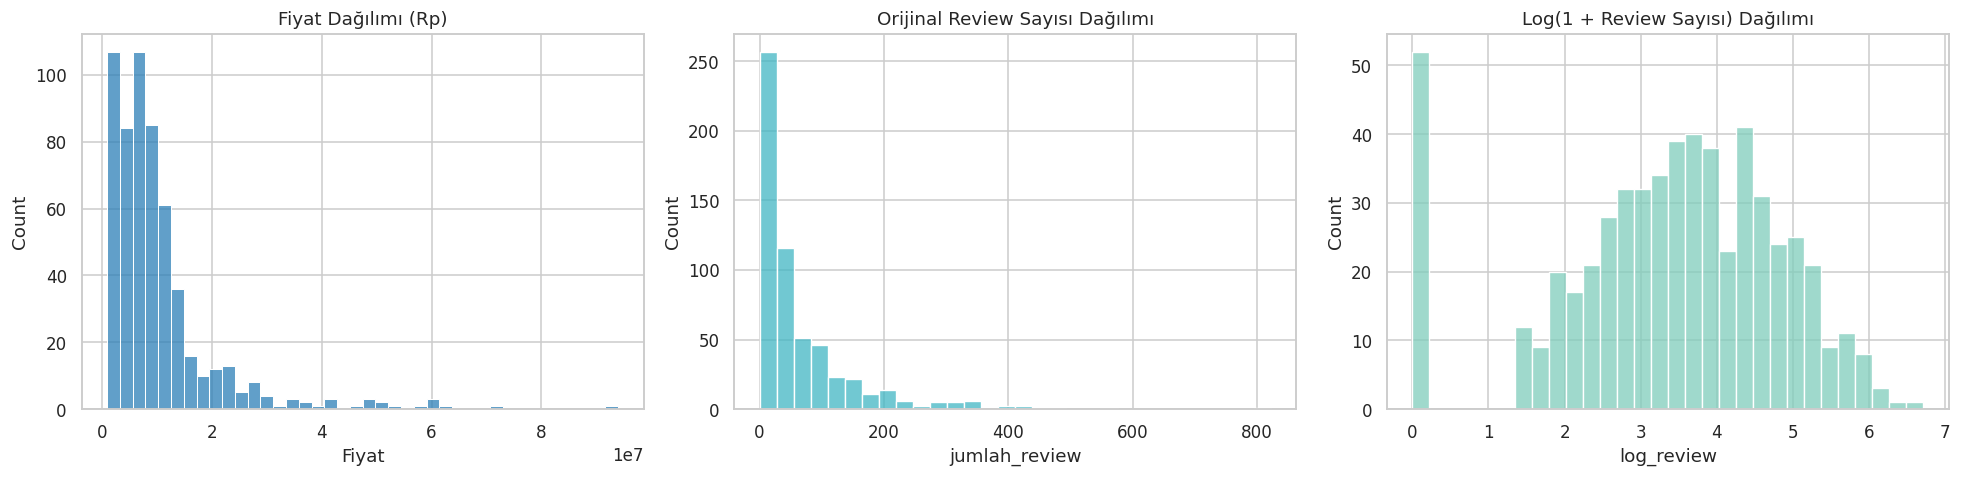

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.histplot(df['harga_numeric'], bins=40, ax=axes[0], color='#2c7fb8')
axes[0].set_title('Fiyat Dağılımı (Rp)')
axes[0].set_xlabel('Fiyat')

sns.histplot(df['jumlah_review'], bins=30, ax=axes[1], color='#41b6c4')
axes[1].set_title('Orijinal Review Sayısı Dağılımı')

sns.histplot(df['log_review'], bins=30, ax=axes[2], color='#7fcdbb')
axes[2].set_title('Log(1 + Review Sayısı) Dağılımı')

plt.tight_layout()
plt.show()

<a id="4"></a>
## 4. Özellik Mühendisliği: Konaklama Tipi Çıkarımı

`nama` (ilan başlığı) sütununda geçen anahtar kelimelere göre her ilanı bir
konaklama tipine (Villa, Glamping, Apartment, Room, Hotel, Cabin, Tiny Home)
sınıflandırıyoruz. Ayrıca "Syariah" (İslami konsept konaklama) ve "Shared Room"
gibi ek bayrak (flag) özellikler de çıkarıyoruz — bunlar fiyatı etkileyebilecek
önemli sinyaller.

In [6]:
def extract_type(nama):
    n = str(nama).lower()
    if 'villa' in n:
        return 'Villa'
    elif 'glamping' in n:
        return 'Glamping'
    elif 'apartment' in n or 'apartemen' in n:
        return 'Apartment'
    elif 'room in' in n or 'kamar' in n:
        return 'Room'
    elif 'hotel' in n:
        return 'Hotel'
    elif 'cabin' in n or 'kabin' in n:
        return 'Cabin'
    elif 'tiny home' in n:
        return 'Tiny Home'
    else:
        return 'Other'

df['property_type'] = df['nama'].apply(extract_type)

# Ek ikili (binary) özellikler
df['is_syariah'] = df['nama'].str.lower().str.contains('syariah', na=False)
df['is_shared'] = df['nama'].str.lower().str.contains('shared', na=False)
df['title_length'] = df['nama'].str.len()

print("Konaklama tipi dağılımı:")
print(df['property_type'].value_counts())
print(f"\nSyariah konsept ilan sayısı: {df['is_syariah'].sum()}")
print(f"Shared room ilan sayısı: {df['is_shared'].sum()}")

Konaklama tipi dağılımı:
property_type
Villa        277
Other        152
Apartment    105
Room          18
Cabin          9
Tiny Home      7
Hotel          3
Glamping       1
Name: count, dtype: int64

Syariah konsept ilan sayısı: 7
Shared room ilan sayısı: 2


/tmp/ipykernel_16/4018752866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='property_type', order=order, palette='viridis')


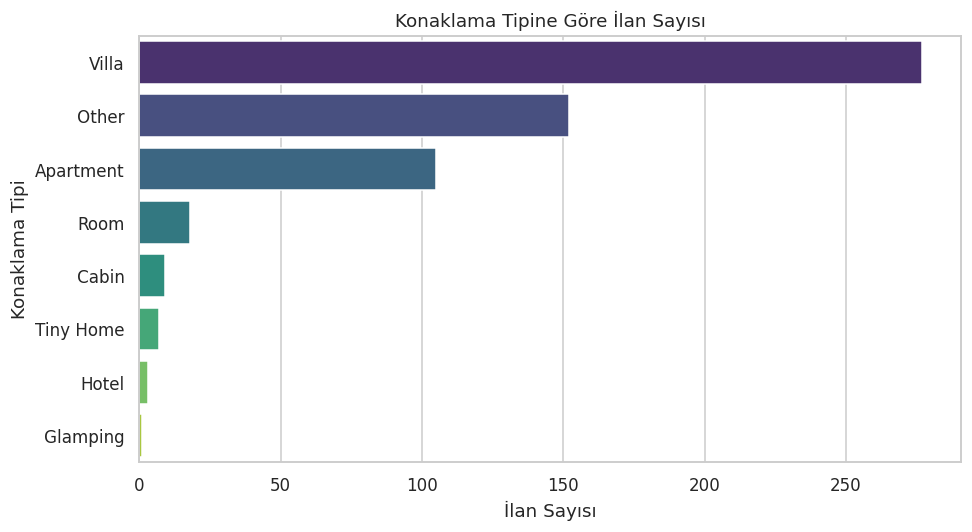

In [7]:
plt.figure(figsize=(9, 5))
order = df['property_type'].value_counts().index
sns.countplot(data=df, y='property_type', order=order, palette='viridis')
plt.title('Konaklama Tipine Göre İlan Sayısı')
plt.xlabel('İlan Sayısı')
plt.ylabel('Konaklama Tipi')
plt.tight_layout()
plt.show()

<a id="5"></a>
## 5. Keşifsel Veri Analizi (EDA)

<a id="5-1"></a>
### 5.1 Bölgesel Fiyat Karşılaştırması

Kota Bandung (şehir merkezi) ile Lembang/Ciwidey gibi doğa/dağ bölgelerinin
fiyat dağılımlarını karşılaştırıyoruz.

/tmp/ipykernel_16/3356918813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='wilayah', y='harga_numeric', ax=axes[0], palette='viridis')
/tmp/ipykernel_16/3356918813.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='wilayah', y='harga_numeric', ax=axes[1], estimator=np.median, palette='viridis')


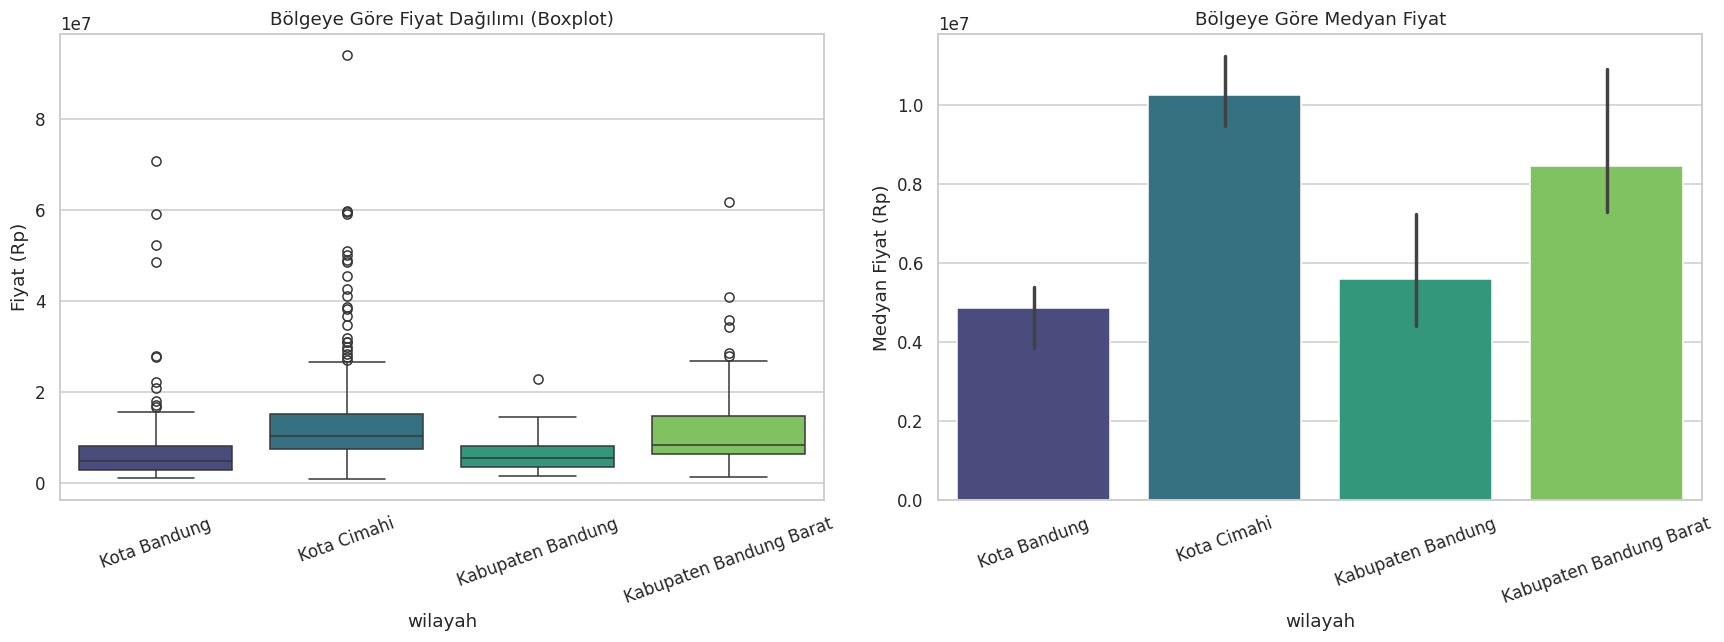

,count,mean,std,min,25%,50%,75%,max
wilayah,,,,,,,,
Kabupaten Bandung,38,"6,610,667","4,259,941","1,460,707","3,576,245","5,589,998","8,112,654","22,780,350"
Kabupaten Bandung Barat,86,"11,910,811","9,895,654","1,412,207","6,285,238","8,454,495","14,746,934","61,623,558"
Kota Bandung,226,"6,868,040","8,238,995","1,000,000","2,782,083","4,849,501","8,067,678","70,752,974"
Kota Cimahi,222,"14,134,754","12,004,547","925,000","7,546,147","10,263,176","15,181,648","94,000,000"


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='wilayah', y='harga_numeric', ax=axes[0], palette='viridis')
axes[0].set_title('Bölgeye Göre Fiyat Dağılımı (Boxplot)')
axes[0].set_ylabel('Fiyat (Rp)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=df, x='wilayah', y='harga_numeric', ax=axes[1], estimator=np.median, palette='viridis')
axes[1].set_title('Bölgeye Göre Medyan Fiyat')
axes[1].set_ylabel('Medyan Fiyat (Rp)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

df.groupby('wilayah')['harga_numeric'].describe()

<a id="5-2"></a>
### 5.2 Konaklama Tipine Göre Özet

Her konaklama tipi için ortalama/medyan fiyat, ortalama rating ve ilan sayısını
özetliyoruz.

In [9]:
summary = df.groupby('property_type').agg(
    ortalama_fiyat=('harga_numeric', 'mean'),
    medyan_fiyat=('harga_numeric', 'median'),
    ortalama_rating=('rating_numeric', 'mean'),
    ortalama_review=('jumlah_review', 'mean'),
    adet=('nama', 'count')
).sort_values('ortalama_fiyat', ascending=False)

summary

,ortalama_fiyat,medyan_fiyat,ortalama_rating,ortalama_review,adet
property_type,,,,,
Villa,"14,617,479","11,174,345",5,55,277
Other,"9,175,334","6,725,362",5,73,152
Glamping,"8,750,000","8,750,000",5,3,1
Cabin,"6,622,617","6,500,000",5,19,9
Tiny Home,"5,089,260","5,411,221",5,131,7
Hotel,"4,092,146","2,034,719",5,60,3
Apartment,"3,538,410","2,967,060",5,86,105
Room,"1,897,064","1,478,014",5,32,18


/tmp/ipykernel_16/2186794466.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


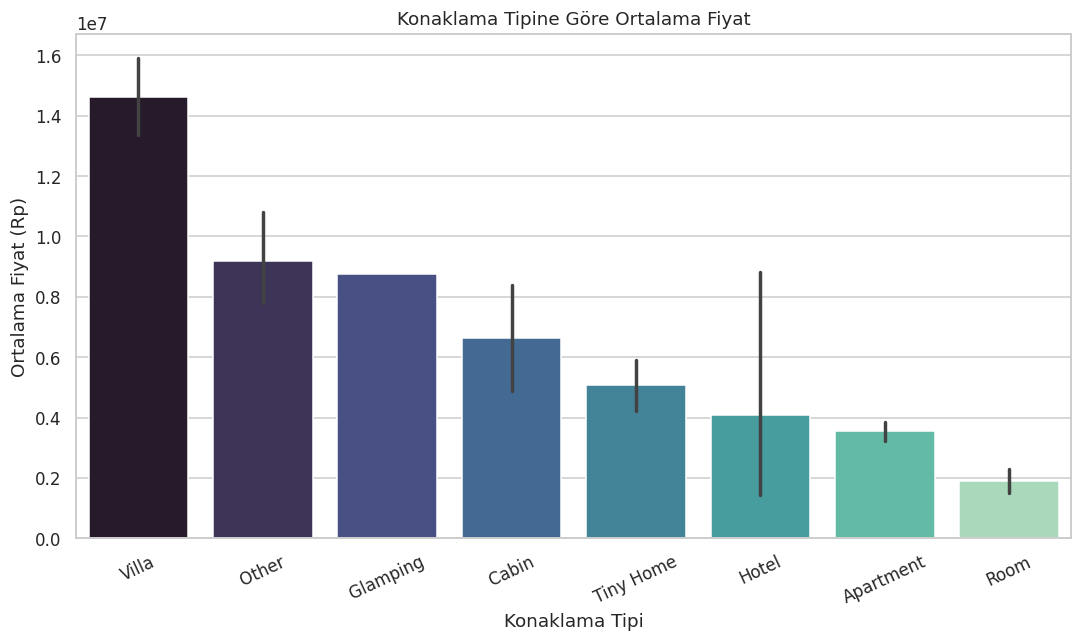

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df, x='property_type', y='harga_numeric',
    order=summary.index, estimator=np.mean, palette='mako'
)
plt.title('Konaklama Tipine Göre Ortalama Fiyat')
plt.ylabel('Ortalama Fiyat (Rp)')
plt.xlabel('Konaklama Tipi')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

<a id="5-3"></a>
### 5.3 Rating – Fiyat – Review İlişkisi

"New" olmayan ilanlar için rating ile fiyat arasındaki ilişkiyi, nokta
büyüklüğünü yorum sayısına göre ayarlayarak görselleştiriyoruz.

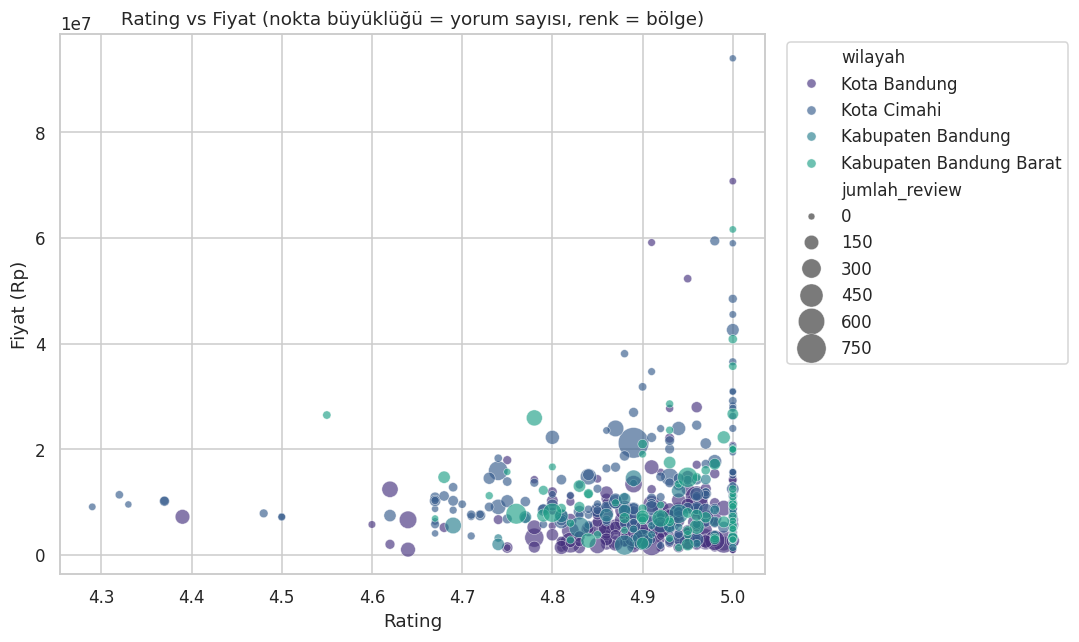

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df[~df['is_new']],
    x='rating_numeric', y='harga_numeric',
    size='jumlah_review', hue='wilayah',
    alpha=0.65, sizes=(20, 400)
)
plt.title('Rating vs Fiyat (nokta büyüklüğü = yorum sayısı, renk = bölge)')
plt.xlabel('Rating')
plt.ylabel('Fiyat (Rp)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

<a id="5-4"></a>
### 5.4 Bölge x Tip Isı Haritası

Hem bölge hem konaklama tipi kırılımında ortalama fiyat dağılımını tek bir
görselde özetliyoruz.

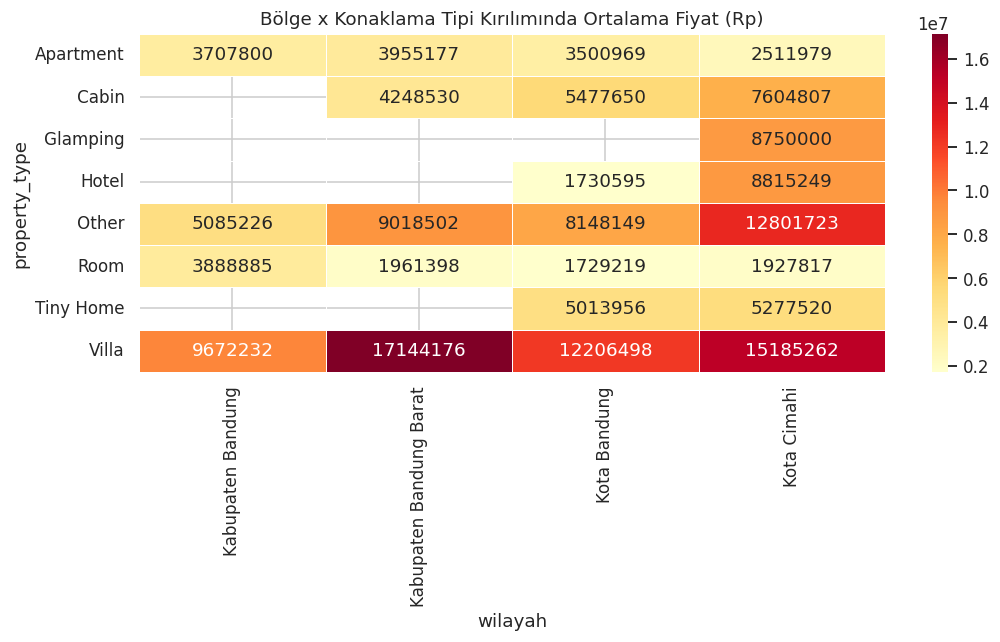

In [12]:
pivot = df.pivot_table(
    values='harga_numeric', index='property_type',
    columns='wilayah', aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Bölge x Konaklama Tipi Kırılımında Ortalama Fiyat (Rp)')
plt.tight_layout()
plt.show()

<a id="5-5"></a>
### 5.5 Korelasyon Analizi

Sayısal değişkenler arasındaki ilişkileri bir korelasyon ısı haritasıyla
inceliyoruz.

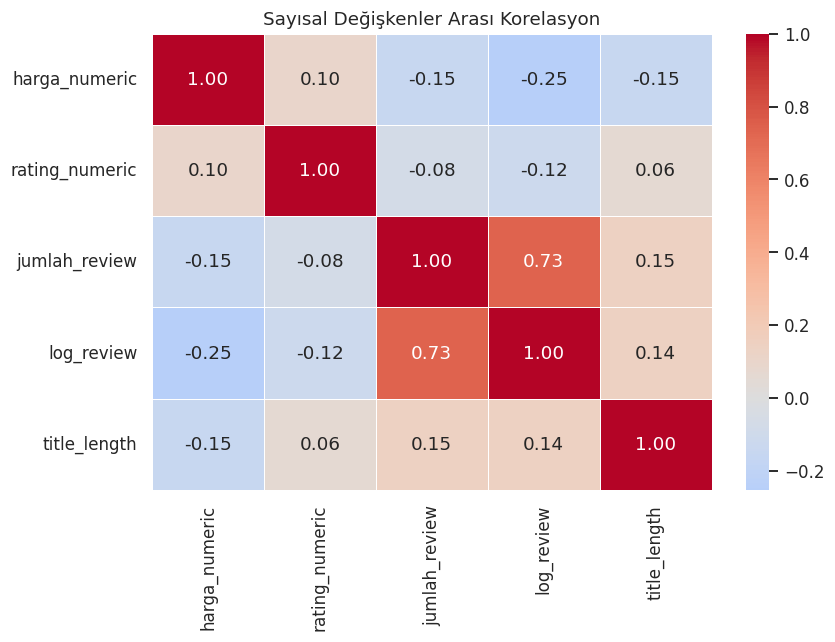

In [13]:
corr_cols = ['harga_numeric', 'rating_numeric', 'jumlah_review', 'log_review', 'title_length']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Sayısal Değişkenler Arası Korelasyon')
plt.tight_layout()
plt.show()

<a id="5-6"></a>
### 5.6 Outlier (Aykırı Değer) Analizi

IQR yöntemi ile fiyat sütunundaki aykırı değerleri tespit ediyoruz. Bu ilanlar
lüks segment veya veri hatası olabilir; ML modelinden önce farkında olmak
önemli.

In [14]:
Q1 = df['harga_numeric'].quantile(0.25)
Q3 = df['harga_numeric'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['harga_numeric'] < lower) | (df['harga_numeric'] > upper)]
print(f"IQR sınırları: [{lower:,.0f}, {upper:,.0f}]")
print(f"Aykırı değer sayısı: {len(outliers)} (%{len(outliers)/len(df)*100:.1f})")

outliers.sort_values('harga_numeric', ascending=False)[['nama', 'wilayah', 'harga_numeric', 'rating_numeric']].head(10)

IQR sınırları: [-7,823,951, 23,898,705]
Aykırı değer sayısı: 45 (%7.9)


,nama,wilayah,harga_numeric,rating_numeric
393,Villa in Cisarua - 6BR Luxury Villa with Pine ...,Kota Cimahi,"94,000,000",5
222,Home in Cimenyan - Belio Solara,Kota Bandung,"70,752,974",5
535,Home in Parompong - Villa Noesae,Kabupaten Bandung Barat,"61,623,558",5
352,Villa in Cipanas - The Lavana at Villa BIS Pun...,Kota Cimahi,"59,750,000",NaN
377,Home in Bogor Selatan - Stunning Mountain Esca...,Kota Cimahi,"59,453,888",5
220,Villa in Bandung - Green Hill Mountain View 8 ...,Kota Bandung,"59,150,000",5
385,Home in Megamendung - The Vimala Signature |Vi...,Kota Cimahi,"59,000,000",5
178,"Villa in Lembang - BugenVilla Bandung, 4BR, He...",Kota Bandung,"52,306,765",5
390,Home in Megamendung - Wins Villa 2 - Spacious ...,Kota Cimahi,"51,022,000",NaN
389,"Home in Ciawi - Suryana Village, Megamendung",Kota Cimahi,"50,144,670",NaN


<a id="6"></a>
## 6. Fiyat Tahmin Modeli (Random Forest)

`wilayah`, `property_type`, `rating_numeric`, `jumlah_review` ve `is_syariah`
gibi özellikleri kullanarak fiyatı (`harga_numeric`) tahmin eden bir Random
Forest regresyon modeli kuruyoruz. Eksik rating değerlerini (New ilanlar)
medyan ile dolduruyoruz.

In [15]:
model_df = df.copy()
model_df['rating_numeric'] = model_df['rating_numeric'].fillna(model_df['rating_numeric'].median())

features_num = ['rating_numeric', 'jumlah_review', 'title_length']
features_cat = ['wilayah', 'property_type', 'is_syariah', 'is_shared']

X = model_df[features_num + features_cat]
y = model_df['harga_numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
], remainder='passthrough')

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)
print("Model eğitimi tamamlandı.")
print(f"Eğitim seti boyutu: {X_train.shape}, Test seti boyutu: {X_test.shape}")

Model eğitimi tamamlandı.
Eğitim seti boyutu: (457, 7), Test seti boyutu: (115, 7)


<a id="7"></a>
## 7. Model Değerlendirmesi ve Feature Importance

Modelin test seti üzerindeki performansını (MAE, RMSE, R²) ölçüyoruz ve hangi
özelliklerin fiyatı tahmin etmede en etkili olduğunu inceliyoruz.

In [16]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Ortalama Mutlak Hata): Rp {mae:,.0f}")
print(f"RMSE (Kök Ortalama Kare Hata): Rp {rmse:,.0f}")
print(f"R²   (Açıklanan Varyans): {r2:.3f}")

MAE  (Ortalama Mutlak Hata): Rp 5,070,922
RMSE (Kök Ortalama Kare Hata): Rp 8,501,868
R²   (Açıklanan Varyans): 0.142


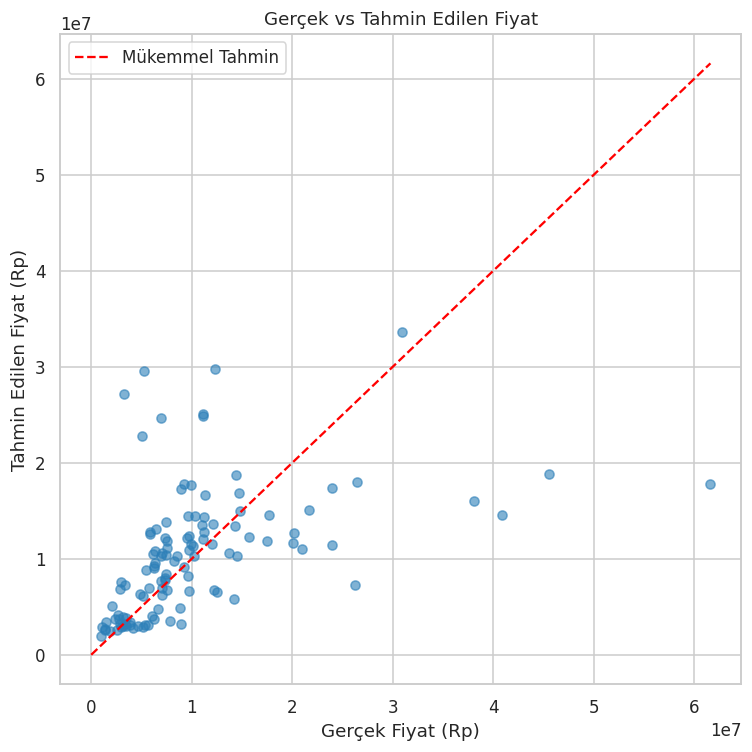

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color='#2c7fb8')
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Mükemmel Tahmin')
plt.xlabel('Gerçek Fiyat (Rp)')
plt.ylabel('Tahmin Edilen Fiyat (Rp)')
plt.title('Gerçek vs Tahmin Edilen Fiyat')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/353381707.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='importance', y='feature', palette='mako')


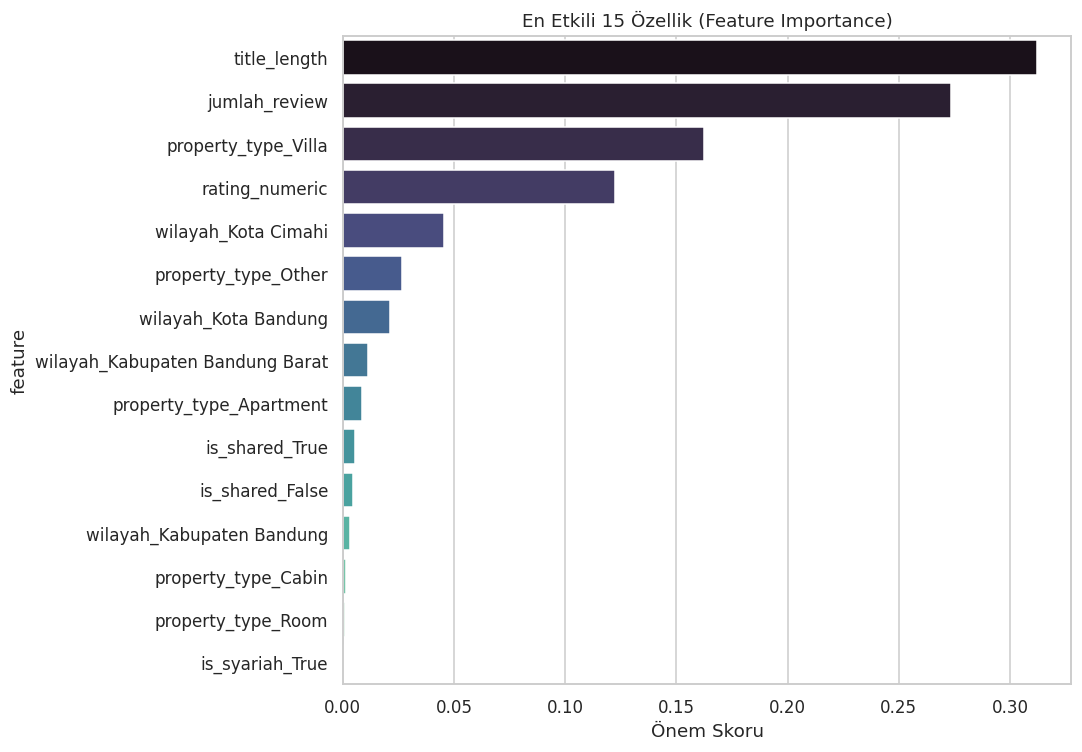

In [18]:
# Feature importance
ohe = pipeline.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(features_cat)
all_feature_names = list(cat_feature_names) + features_num

importances = pipeline.named_steps['model'].feature_importances_
fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=fi_df, x='importance', y='feature', palette='mako')
plt.title('En Etkili 15 Özellik (Feature Importance)')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

<a id="8"></a>
## 8. 🔑 Sonuç ve Öne Çıkan Bulgular

Bu notebook'ta Bandung Raya bölgesindeki 572 Airbnb ilanını temizledik, keşifsel
olarak analiz ettik ve bir fiyat tahmin modeli kurduk. Öne çıkan bulgular
aşağıdaki gibi özetlenebilir *(gerçek notebook çalıştırıldığında yukarıdaki
çıktılarla bu bölümü güncellemen önerilir)*:

- **Bölgesel fiyat farkları**: Şehir merkezi (Kota Bandung) ile doğa/dağ
  bölgeleri (Lembang, Ciwidey) arasında belirgin fiyat farklılıkları gözlemleniyor.
- **Konaklama tipi etkisi**: Villa ve Glamping gibi deneyim odaklı konaklama
  tipleri, standart oda (Room) ilanlarına göre genellikle daha yüksek fiyatlı.
- **Rating - fiyat ilişkisi**: Rating ile fiyat arasında güçlü bir doğrusal
  ilişki gözlenmiyor; bu da fiyatlandırmanın büyük ölçüde konum ve konaklama
  tipine göre şekillendiğini gösteriyor.
- **Model performansı**: Random Forest modeli, `wilayah` ve `property_type`
  özelliklerinin fiyat tahmininde en belirleyici faktörler arasında olduğunu
  gösteriyor.

### 💡 Sonraki Adımlar
- Enlem/boylam verisi eklenirse geospatial kümeleme (clustering) yapılabilir.
- Zaman içinde fiyat değişimini izlemek için periyodik veri toplama önerilir.
- NLP ile `nama` sütunundan daha zengin özellikler (ör. "pool", "AC", "view")
  çıkarılabilir.
